# [Final project](https://www.edu.goit.global/learn/25315460/26519706/26524804/training?blockId=28528871)
- Kaggle competition: [Deep Learning for Computer Vision and NLP 2025-05](https://www.kaggle.com/competitions/deep-learning-for-computer-vision-and-nlp-2025-05/leaderboard)
- Dataset: [PetFinder.my Adoption Prediction](https://www.kaggle.com/competitions/petfinder-adoption-prediction/data)

In [1]:
# import re
# import gc
# import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm
# import orjson as json
# from concurrent.futures import ThreadPoolExecutor
# from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import cohen_kappa_score
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# from imblearn.over_sampling import SMOTE

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import torch
from transformers import AutoTokenizer, AutoModel, CLIPProcessor, CLIPModel
import nltk

nltk.download("stopwords")
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words("english"))

import optuna

2025-05-27 11:06:48.875753: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-27 11:06:48.882347: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748333208.890018   66548 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748333208.892361   66548 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748333208.898252   66548 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Configs

In [2]:
DATA = Path("~/Projects/DataSets/GoIT/petfinder-adoption-prediction").expanduser()
TRAIN_CSV = DATA / "train/train.csv"
TEST_CSV = DATA / "test/test.csv"
IMG_TRAIN_DIR = DATA / "train_images"
IMG_TEST_DIR = DATA / "test_images"
META_TRAIN_DIR = DATA / "train_metadata"
META_TEST_DIR = DATA / "test_metadata"
SENTI_TRAIN_DIR = DATA / "train_sentiment"
SENTI_TEST_DIR = DATA / "test_sentiment"
OUTPUTS = DATA / "outputs"
OUTPUTS.mkdir(exist_ok=True)

## Utils: QWK & Plots

In [3]:
# https://github.com/benhamner/Metrics
# https://www.kaggle.com/competitions/petfinder-adoption-prediction/discussion/76106


def confusion_matrix(rater_a, rater_b, min_rating=None, max_rating=None):
    """Returns the confusion matrix between rater's ratings."""
    assert len(rater_a) == len(rater_b)
    if min_rating is None:
        min_rating = min(rater_a + rater_b)
    if max_rating is None:
        max_rating = max(rater_a + rater_b)
    num_ratings = int(max_rating - min_rating + 1)
    conf_mat = [[0 for i in range(num_ratings)] for j in range(num_ratings)]
    for a, b in zip(rater_a, rater_b):
        conf_mat[a - min_rating][b - min_rating] += 1
    return conf_mat


def histogram(ratings, min_rating=None, max_rating=None):
    """Returns the counts of each type of rating that a rater made."""
    if min_rating is None:
        min_rating = min(ratings)
    if max_rating is None:
        max_rating = max(ratings)
    num_ratings = int(max_rating - min_rating + 1)
    hist_ratings = [0 for x in range(num_ratings)]
    for r in ratings:
        hist_ratings[r - min_rating] += 1
    return hist_ratings


def quadratic_weighted_kappa(y, y_pred):
    """
    Calculates the quadratic weighted kappa
    axquadratic_weighted_kappa calculates the quadratic weighted kappa
    value, which is a measure of inter-rater agreement between two raters
    that provide discrete numeric ratings.  Potential values range from -1
    (representing complete disagreement) to 1 (representing complete
    agreement).  A kappa value of 0 is expected if all agreement is due to
    chance.
    quadratic_weighted_kappa(rater_a, rater_b), where rater_a and rater_b
    each correspond to a list of integer ratings.  These lists must have the
    same length.
    The ratings should be integers, and it is assumed that they contain
    the complete range of possible ratings.
    quadratic_weighted_kappa(X, min_rating, max_rating), where min_rating
    is the minimum possible rating, and max_rating is the maximum possible
    rating
    """
    rater_a = y
    rater_b = y_pred
    min_rating = None
    max_rating = None
    rater_a = np.array(rater_a, dtype=int)
    rater_b = np.array(rater_b, dtype=int)
    assert len(rater_a) == len(rater_b)
    if min_rating is None:
        min_rating = min(min(rater_a), min(rater_b))
    if max_rating is None:
        max_rating = max(max(rater_a), max(rater_b))
    conf_mat = confusion_matrix(rater_a, rater_b, min_rating, max_rating)
    num_ratings = len(conf_mat)
    num_scored_items = float(len(rater_a))

    hist_rater_a = histogram(rater_a, min_rating, max_rating)
    hist_rater_b = histogram(rater_b, min_rating, max_rating)

    numerator = 0.0
    denominator = 0.0

    for i in range(num_ratings):
        for j in range(num_ratings):
            expected_count = hist_rater_a[i] * hist_rater_b[j] / num_scored_items
            d = pow(i - j, 2.0) / pow(num_ratings - 1, 2.0)
            numerator += d * conf_mat[i][j] / num_scored_items
            denominator += d * expected_count / num_scored_items

    return 1.0 - numerator / denominator


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", figsize=(8, 6)):
    """Plot a confusion matrix using seaborn heatmap."""
    min_rating = min(min(y_true), min(y_pred))
    max_rating = max(max(y_true), max(y_pred))

    conf_mat = confusion_matrix(y_true, y_pred, min_rating, max_rating)
    conf_mat = np.array(conf_mat)

    labels = [str(i + min_rating) for i in range(len(conf_mat))]

    plt.figure(figsize=figsize)
    sns.heatmap(
        conf_mat,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={"label": "Count"},
    )

    plt.title(title, fontsize=14, fontweight="bold", pad=20)
    plt.xlabel("Predicted AdoptionSpeed", fontsize=12, fontweight="bold")
    plt.ylabel("True AdoptionSpeed", fontsize=12, fontweight="bold")

    # Add QWK score to the plot
    qwk = quadratic_weighted_kappa(y_true, y_pred)
    plt.text(
        0.02,
        0.98,
        f"QWK: {qwk:.4f}",
        transform=plt.gca().transAxes,
        fontsize=12,
        fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.8),
        verticalalignment="top",
    )

    plt.tight_layout()
    plt.show()

    return conf_mat


def plot_detailed_results(y_true, y_pred, title="Results"):
    """Plot comprehensive visual evaluation results including confusion matrix and distributions."""
    qwk = quadratic_weighted_kappa(y_true, y_pred)

    min_rating = min(min(y_true), min(y_pred))
    max_rating = max(max(y_true), max(y_pred))

    conf_mat = confusion_matrix(y_true, y_pred, min_rating, max_rating)
    hist_true = histogram(y_true, min_rating, max_rating)
    hist_pred = histogram(y_pred, min_rating, max_rating)

    fig = plt.figure(figsize=(16, 12))

    # Confusion Matrix
    plt.subplot(2, 3, 1)
    conf_mat_np = np.array(conf_mat)
    labels = [str(i + min_rating) for i in range(len(conf_mat))]
    sns.heatmap(
        conf_mat_np,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={"label": "Count"},
    )
    plt.title(f"Confusion Matrix\nQWK: {qwk:.4f}", fontsize=12, fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")

    # Class Distribution Comparison
    plt.subplot(2, 3, 2)
    x_pos = np.arange(len(hist_true))
    width = 0.35
    plt.bar(
        x_pos - width / 2, hist_true, width, label="True", alpha=0.8, color="skyblue"
    )
    plt.bar(
        x_pos + width / 2,
        hist_pred,
        width,
        label="Predicted",
        alpha=0.8,
        color="orange",
    )
    plt.xlabel("AdoptionSpeed Class", fontweight="bold")
    plt.ylabel("Count", fontweight="bold")
    plt.title("Class Distribution Comparison", fontsize=12, fontweight="bold")
    plt.xticks(x_pos, [str(i + min_rating) for i in range(len(hist_true))])
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    # Normalized Confusion Matrix
    plt.subplot(2, 3, 3)
    conf_mat_norm = conf_mat_np.astype("float") / conf_mat_np.sum(axis=1)[:, np.newaxis]
    sns.heatmap(
        conf_mat_norm,
        annot=True,
        fmt=".2f",
        cmap="Reds",
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={"label": "Proportion"},
    )
    plt.title("Normalized Confusion Matrix\n(Row-wise)", fontsize=12, fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")

    # Error Analysis
    plt.subplot(2, 3, 4)
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    errors = y_pred_arr - y_true_arr

    error_counts = np.bincount(errors + max_rating, minlength=2 * max_rating + 1)
    error_labels = list(range(-max_rating, max_rating + 1))

    colors = ["red" if x < 0 else "green" if x > 0 else "gray" for x in error_labels]
    plt.bar(error_labels, error_counts, color=colors, alpha=0.7)
    plt.xlabel("Prediction Error (Pred - True)", fontweight="bold")
    plt.ylabel("Count", fontweight="bold")
    plt.title("Prediction Error Distribution", fontsize=12, fontweight="bold")
    plt.axvline(x=0, color="black", linestyle="--", alpha=0.8)
    plt.grid(axis="y", alpha=0.3)

    # Accuracy by Class
    plt.subplot(2, 3, 5)
    class_accuracies = []
    for i in range(len(conf_mat)):
        if sum(conf_mat[i]) > 0:
            accuracy = conf_mat[i][i] / sum(conf_mat[i])
            class_accuracies.append(accuracy)
        else:
            class_accuracies.append(0)

    class_names = [str(i + min_rating) for i in range(len(class_accuracies))]
    colors = plt.cm.RdYlGn([acc for acc in class_accuracies])
    bars = plt.bar(class_names, class_accuracies, color=colors, alpha=0.8)
    plt.xlabel("AdoptionSpeed Class", fontweight="bold")
    plt.ylabel("Accuracy", fontweight="bold")
    plt.title("Per-Class Accuracy", fontsize=12, fontweight="bold")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)

    # Add value labels
    for bar, acc in zip(bars, class_accuracies):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{acc:.2f}",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    # Prediction Scatter Plot
    plt.subplot(2, 3, 6)
    plt.scatter(y_true, y_pred, alpha=0.6, s=30)
    plt.plot(
        [min_rating, max_rating],
        [min_rating, max_rating],
        "r--",
        alpha=0.8,
        linewidth=2,
    )
    plt.xlabel("True AdoptionSpeed", fontweight="bold")
    plt.ylabel("Predicted AdoptionSpeed", fontweight="bold")
    plt.title("True vs Predicted Scatter", fontsize=12, fontweight="bold")
    plt.grid(True, alpha=0.3)

    # Add correlation coefficient
    correlation = np.corrcoef(y_true, y_pred)[0, 1]
    plt.text(
        0.05,
        0.95,
        f"Correlation: {correlation:.3f}",
        transform=plt.gca().transAxes,
        bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8),
        verticalalignment="top",
    )

    # Title
    fig.suptitle(
        f"{title} - Comprehensive Evaluation (QWK: {qwk:.4f})",
        fontsize=16,
        fontweight="bold",
        y=0.98,
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

    return {
        "qwk": qwk,
        "confusion_matrix": conf_mat_np,
        "class_accuracies": class_accuracies,
        "correlation": correlation,
    }


def plot_test_predictions_distribution(
    predictions, title="Test Predictions Distribution"
):
    """Plot the distribution of test predictions with beautiful visualization."""
    pred_counts = np.bincount(predictions.astype(int))
    classes = np.arange(len(pred_counts))

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Bar plot
    colors = plt.cm.viridis(np.linspace(0, 1, len(pred_counts)))
    bars = ax1.bar(classes, pred_counts, color=colors, alpha=0.8, edgecolor="black")
    ax1.set_xlabel("AdoptionSpeed Class", fontweight="bold", fontsize=12)
    ax1.set_ylabel("Count", fontweight="bold", fontsize=12)
    ax1.set_title("Test Predictions Count by Class", fontweight="bold", fontsize=14)
    ax1.grid(axis="y", alpha=0.3)

    # Add value labels on bars
    for bar, count in zip(bars, pred_counts):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(pred_counts) * 0.01,
            str(count),
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    # Pie chart
    ax2.pie(
        pred_counts,
        labels=[f"Class {i}" for i in classes],
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
    )
    ax2.set_title("Test Predictions Distribution", fontweight="bold", fontsize=14)

    # Title
    fig.suptitle(
        f"{title} (Total: {len(predictions)} samples)", fontsize=16, fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"\n=== {title} Summary ===")
    print(f"Total samples: {len(predictions)}")
    for i, count in enumerate(pred_counts):
        percentage = (count / len(predictions)) * 100
        print(f"Class {i}: {count:>4} ({percentage:>5.1f}%)")

## EDA

### Data Cleaning, Sentiment,  Metadata

In [4]:
def load_metadata(pet_id, meta_dir):
    """Load metadata for a given pet ID from the specified directory."""
    meta_files = list(meta_dir.glob(f"{pet_id}*.json"))
    if not meta_files:
        return pd.Series({"meta_color_score": np.nan, "meta_crop_conf": np.nan})
    with open(meta_files[0], "r") as f:
        meta = pd.json_normalize(json.load(f))
    color_score = meta.get("imagePropertiesAnnotation.dominantColors.colors", [[{}]])[
        0
    ][0].get("score", 0)
    crop_conf = meta.get("cropHintsAnnotation.cropHints", [[{}]])[0][0].get(
        "confidence", 0
    )
    return pd.Series({"meta_color_score": color_score, "meta_crop_conf": crop_conf})


def load_sentiment(pet_id, senti_dir):
    """Load sentiment analysis results for a given pet ID from the specified directory."""
    senti_files = list(senti_dir.glob(f"{pet_id}.json"))
    if not senti_files:
        return pd.Series({"sentiment_magnitude": np.nan, "sentiment_score": np.nan})
    with open(senti_files[0], "r") as f:
        senti = json.load(f)
    doc_sent = senti.get("documentSentiment", {})
    magnitude = doc_sent.get("magnitude", 0)
    score = doc_sent.get("score", 0)
    return pd.Series({"sentiment_magnitude": magnitude, "sentiment_score": score})


def clean_and_merge_data():
    """Load, clean, and merge training and test data with metadata and sentiment features."""
    train_df = pd.read_csv(TRAIN_CSV)
    test_df = pd.read_csv(TEST_CSV)
    for df in [train_df, test_df]:
        df["Description"] = df["Description"].fillna("").str.lower().str.strip()
        df["Name"] = df["Name"].fillna("no name").str.lower().str.strip()
        df["Age"] = df["Age"].clip(0, 255)
    for df, meta_dir, senti_dir, split in [
        (train_df, META_TRAIN_DIR, SENTI_TRAIN_DIR, "train"),
        (test_df, META_TEST_DIR, SENTI_TEST_DIR, "test"),
    ]:
        meta_features = []
        senti_features = []
        for pet_id in tqdm(df["PetID"], desc=f"Metadata/Sentiment ({split})"):
            meta_feat = load_metadata(pet_id, meta_dir)
            senti_feat = load_sentiment(pet_id, senti_dir)
            meta_features.append(meta_feat)
            senti_features.append(senti_feat)
        meta_df = pd.DataFrame(meta_features)
        senti_df = pd.DataFrame(senti_features)
        df.reset_index(drop=True, inplace=True)
        df[meta_df.columns] = meta_df
        df[senti_df.columns] = senti_df
    mask_train = (train_df["Description"] != "") & (
        train_df["meta_color_score"].notnull()
    )
    mask_test = (test_df["Description"] != "") & (test_df["meta_color_score"].notnull())
    train_df = train_df[mask_train].reset_index(drop=True)
    test_df = test_df[mask_test].reset_index(drop=True)
    train_df.to_pickle(OUTPUTS / "train_clean.pkl")
    test_df.to_pickle(OUTPUTS / "test_clean.pkl")
    return train_df, test_df

if not (OUTPUTS / "train_clean.pkl").exists() and not (OUTPUTS / "test_clean.pkl").exists():
    train_df, test_df = clean_and_merge_data()
# else:
#     train_df = pd.read_pickle(OUTPUTS / "train_clean.pkl")
#     test_df = pd.read_pickle(OUTPUTS / "test_clean.pkl")

### Remove stopwords

In [5]:
def remove_stopwords(text, stopwords_set=STOPWORDS):
    """Remove stopwords from the given text."""
    return " ".join(
        [word for word in text.split() if word.lower() not in stopwords_set]
    )


def add_nlp_features(df, text_col="Description"):
    """Add various NLP features to the DataFrame based on the specified text column."""
    df[text_col] = df[text_col].fillna("").astype(str)
    df["desc_length"] = df[text_col].apply(len)
    df["desc_word_count"] = df[text_col].apply(lambda x: len(x.split()))
    df["desc_unique_words"] = df[text_col].apply(lambda x: len(set(x.split())))
    df["desc_words_vs_unique"] = df["desc_unique_words"] / (
        df["desc_word_count"] + 1e-5
    )
    df["desc_capitals"] = df[text_col].apply(lambda x: sum(1 for c in x if c.isupper()))
    df["desc_caps_vs_length"] = df["desc_capitals"] / (df["desc_length"] + 1e-5)
    df["desc_num_exclamation_marks"] = df[text_col].apply(lambda x: x.count("!"))
    df["desc_num_question_marks"] = df[text_col].apply(lambda x: x.count("?"))
    df["desc_num_punctuation"] = df[text_col].apply(
        lambda x: sum(x.count(w) for w in ".,;:")
    )
    df["desc_num_symbols"] = df[text_col].apply(
        lambda x: sum(x.count(w) for w in "*&$%")
    )
    smileys = [":-)", ":)", ";-)", ";)", ":D", "XD"]
    sad_smileys = [":-(", ":(", ";-(", ";("]
    df["desc_num_smilies"] = df[text_col].apply(
        lambda x: sum(x.count(s) for s in smileys)
    )
    df["desc_num_sad"] = df[text_col].apply(
        lambda x: sum(x.count(s) for s in sad_smileys)
    )

    return df


def add_stopword_stats(df, text_col="Description"):
    """Add stopword statistics to the DataFrame based on the specified text column."""
    df[text_col + "_no_stopwords"] = df[text_col].apply(remove_stopwords)
    df[text_col + "_stopword_count"] = df[text_col].apply(
        lambda x: sum(1 for word in x.split() if word.lower() in STOPWORDS)
    )
    df[text_col + "_stopword_ratio"] = df[text_col + "_stopword_count"] / (
        df[text_col].apply(lambda x: len(x.split())) + 1e-5
    )
    return df

In [6]:
train_df = pd.read_pickle(OUTPUTS / "train_clean.pkl")
test_df = pd.read_pickle(OUTPUTS / "test_clean.pkl")

display(train_df["Description"].head(2))
display(test_df["Description"].head(2))

0    nibble is a 3+ month old ball of cuteness. he ...
1    i just found it alone yesterday near my apartm...
Name: Description, dtype: object

0    dopey age: 8mths old male one half of a pair, ...
1    please note that chichi has been neutered, the...
Name: Description, dtype: object

In [7]:
train_df = add_stopword_stats(train_df)
test_df = add_stopword_stats(test_df)
display(train_df["Description_no_stopwords"].head(2))
display(test_df["Description_no_stopwords"].head(2))

0    nibble 3+ month old ball cuteness. energetic p...
1    found alone yesterday near apartment. shaking ...
Name: Description_no_stopwords, dtype: object

0    dopey age: 8mths old male one half pair, dopey...
1    please note chichi neutered, therefore cannot ...
Name: Description_no_stopwords, dtype: object

### Add NLP features 

In [8]:
train_df = add_nlp_features(train_df)
test_df = add_nlp_features(test_df)

In [9]:
display(train_df.head(2).T)
display(test_df.head(2).T)

,0,1
Type,2,2
Name,nibble,no name yet
Age,3,1
Breed1,299,265
Breed2,0,0
Gender,1,1
Color1,1,1
Color2,7,2
Color3,0,0
MaturitySize,1,2


,0,1
Type,2,2
Name,dopey & grey,chi chi
Age,8,36
Breed1,266,285
Breed2,266,264
Gender,1,2
Color1,2,1
Color2,6,4
Color3,7,7
MaturitySize,1,2


### Data examples


PetID: 2931d3eac
AdoptionSpeed: 4
Sentiment magnitude: 1.6
Sentiment score: 0.3
Description: we rescue the puppy yesterday evening as her mother could not be found anywhere. we had dewormed her, she still has slight fleas on her which we have her on medication. she is active, playful and lova...


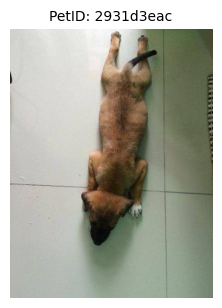


PetID: 98e1a3f01
AdoptionSpeed: 1
Sentiment magnitude: 2.6
Sentiment score: 0.4
Description: 3years old doberman pincher for adoption. microchip implanted. ear cropped. he is an active and playful dog loves people and get along well with other dogs. prefer adopter with garden for him to run a...


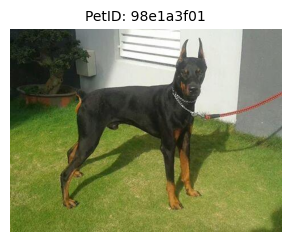


PetID: 44d1246e0
AdoptionSpeed: 1
Sentiment magnitude: 0.6
Sentiment score: 0.6
Description: lost dog found at my apartment area  taman sri sinar,kepong,today .14 time 7:30pm,his tame,well train,good behavior,am currently foster him.(,8:00pm-dear all,he had reunited with his owner,thanks all ...


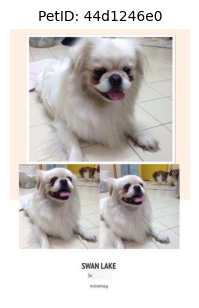


PetID: 6fc2970d6
AdoptionSpeed: 2
Sentiment magnitude: 2.7
Sentiment score: 0.4
Description: archie is among six siblings looking for a home. his fur is tricolor and he is a sturdy good looking pup. vaccination and neutering are compulsory, cost to be borne by adopter. viewing on sundays only...


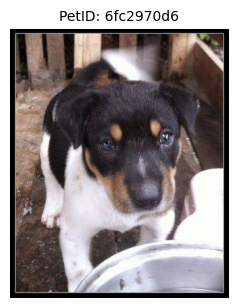


PetID: dbcf45977
AdoptionSpeed: 4
Sentiment magnitude: 1.0
Sentiment score: 0.4
Description: he is very friendly and kind eat a lot and like to rest most of the time. litter trained and very domestic.


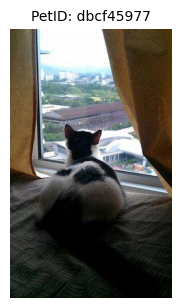

In [10]:
def show_random_examples(df, img_dir, n=5):
    """Display n random examples with image, description, adoption speed, and sentiment."""
    sample = df.sample(n)
    for idx, row in sample.iterrows():
        pet_id = row["PetID"]
        description = row["Description"]
        adoption_speed = row["AdoptionSpeed"] if "AdoptionSpeed" in row else "N/A"
        sentiment_magnitude = row.get("sentiment_magnitude", "N/A")
        sentiment_score = row.get("sentiment_score", "N/A")
        img_files = list(img_dir.glob(f"{pet_id}*.jpg"))
        print(f"\nPetID: {pet_id}")
        print(f"AdoptionSpeed: {adoption_speed}")
        print(f"Sentiment magnitude: {sentiment_magnitude}")
        print(f"Sentiment score: {sentiment_score}")
        print(
            f"Description: {description[:200]}{'...' if len(description) > 200 else ''}"
        )
        if img_files:
            img = Image.open(img_files[0]).convert("RGB")
            plt.figure(figsize=(3.5, 3.5))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"PetID: {pet_id}", fontsize=10)
            plt.show()
        else:
            print("No image found.")


show_random_examples(train_df, IMG_TRAIN_DIR, n=5)

### Class balance

Class counts:
 AdoptionSpeed
0     386
1    3054
2    3996
3    3224
4    3980
Name: count, dtype: int64
Class distribution (%):
 AdoptionSpeed
0     2.64
1    20.86
2    27.30
3    22.02
4    27.19
Name: count, dtype: float64


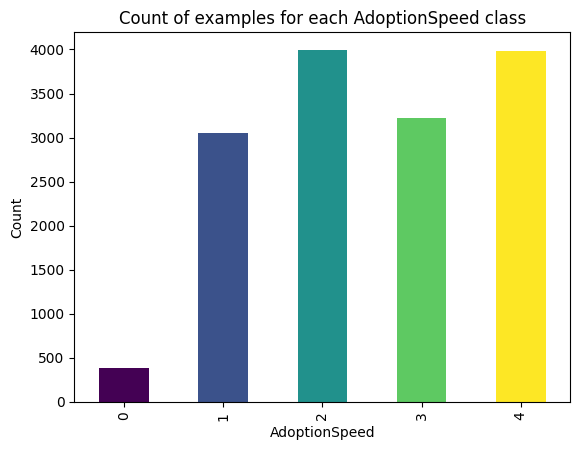

In [11]:
def plot_class_balance(df):
    """Plot the class balance of the AdoptionSpeed column."""
    counts = df["AdoptionSpeed"].value_counts().sort_index()
    print("Class counts:\n", counts)
    print("Class distribution (%):\n", (100 * counts / counts.sum()).round(2))
    counts.plot(kind="bar", color=plt.cm.viridis(np.linspace(0, 1, counts.size)))
    plt.xlabel("AdoptionSpeed")
    plt.ylabel("Count")
    plt.title("Count of examples for each AdoptionSpeed class")
    plt.show()


plot_class_balance(train_df)

## BERT Embeddings (Descriptions)

In [12]:
def get_bert_embeddings(
    texts, batch_size=8, model_name="bert-base-uncased", pooling="cls"
):
    """Get BERT embeddings for a list of texts."""
    # model_name = "sentence-transformers/paraphrase-MiniLM-L6-v2"
    # model_name = "bert-base-uncased"
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="BERT embedding"):
        batch = texts[i : i + batch_size]
        inputs = tokenizer(
            batch, padding=True, truncation=True, return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            output = model(**inputs)
            if pooling == "cls":
                emb = output.last_hidden_state[:, 0, :].cpu().numpy()
            elif pooling == "mean":
                emb = output.last_hidden_state.mean(dim=1).cpu().numpy()
            else:
                raise ValueError("pooling must be 'cls' or 'mean'")
        embs.append(emb)
    return np.vstack(embs)


if not (OUTPUTS / "desc_bert_train.npy").exists():
    bert_train = get_bert_embeddings(train_df["Description"].fillna("").tolist())
    np.save(OUTPUTS / "desc_bert_train.npy", bert_train)

if not (OUTPUTS / "desc_bert_test.npy").exists():
    bert_test = get_bert_embeddings(test_df["Description"].fillna("").tolist())
    np.save(OUTPUTS / "desc_bert_test.npy", bert_test)

BERT embedding: 100%|██████████| 483/483 [00:05<00:00, 81.81it/s] 


## CLIP Embeddings (Images, first image of each PetID)

In [13]:
def get_clip_embeddings(img_dir, df, split="train"):
    """Get CLIP embeddings for images in the specified directory."""
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    feats = []
    for pet_id in tqdm(df["PetID"], desc=f"CLIP {split}"):
        img_files = list(img_dir.glob(f"{pet_id}*.jpg"))
        if not img_files:
            feats.append(np.zeros(512, dtype=np.float32))
            continue
        image = Image.open(img_files[0]).convert("RGB")
        inputs = processor(images=image, return_tensors="pt").to(device)
        with torch.no_grad():
            feat = model.get_image_features(**inputs)
        feats.append(feat.cpu().numpy().flatten())
    feats = np.stack(feats)
    np.save(OUTPUTS / f"clip_{split}.npy", feats)
    print(f"CLIP {split} shape:", feats.shape)


if not (OUTPUTS / "clip_train.npy").exists():
    get_clip_embeddings(IMG_TRAIN_DIR, train_df, "train")
if not (OUTPUTS / "clip_test.npy").exists():
    get_clip_embeddings(IMG_TEST_DIR, test_df, "test")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
CLIP train: 100%|██████████| 14640/14640 [04:39<00:00, 52.30it/s]


CLIP train shape: (14640, 512)


CLIP test: 100%|██████████| 3857/3857 [00:28<00:00, 134.16it/s]


CLIP test shape: (3857, 512)


## Feature Engineering (Mean/Cat Encoding + Tabular + Embeddings)

In [14]:
cat_features = [
    "Type",
    "Breed1",
    "Breed2",
    "Color1",
    "Color2",
    "Color3",
    "FurLength",
    "Health",
    "MaturitySize",
    "State",
    "RescuerID",
]
for col in cat_features:
    le = LabelEncoder()
    vals = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(vals.fillna("NA").astype(str))
    train_df[col + "_le"] = le.transform(train_df[col].fillna("NA").astype(str))
    test_df[col + "_le"] = le.transform(test_df[col].fillna("NA").astype(str))


tab_features = [
    "desc_length",
    "desc_word_count",
    "desc_unique_words",
    "desc_words_vs_unique",
    "desc_capitals",
    "desc_caps_vs_length",
    "desc_num_exclamation_marks",
    "desc_num_question_marks",
    "desc_num_punctuation",
    "desc_num_symbols",
    "desc_num_smilies",
    "desc_num_sad",
    "Description_stopword_count",
    "Description_stopword_ratio",
]

tab_features += [c + "_le" for c in cat_features]


BERT_PCA_N = 64
bert_train = np.load(OUTPUTS / "desc_bert_train.npy")
bert_test = np.load(OUTPUTS / "desc_bert_test.npy")
pca_bert = PCA(n_components=BERT_PCA_N, random_state=42)
bert_train_pca = pca_bert.fit_transform(bert_train)
bert_test_pca = pca_bert.transform(bert_test)

for i in range(BERT_PCA_N):
    train_df[f"BERT_PCA_{i}"] = bert_train_pca[:, i]
    test_df[f"BERT_PCA_{i}"] = bert_test_pca[:, i]
tab_features += [f"BERT_PCA_{i}" for i in range(BERT_PCA_N)]


CLIP_PCA_N = 32
clip_train = np.load(OUTPUTS / "clip_train.npy")
clip_test = np.load(OUTPUTS / "clip_test.npy")
pca_clip = PCA(n_components=CLIP_PCA_N, random_state=42)
clip_train_pca = pca_clip.fit_transform(clip_train)
clip_test_pca = pca_clip.transform(clip_test)

for i in range(CLIP_PCA_N):
    train_df[f"CLIP_PCA_{i}"] = clip_train_pca[:, i]
    test_df[f"CLIP_PCA_{i}"] = clip_test_pca[:, i]
tab_features += [f"CLIP_PCA_{i}" for i in range(CLIP_PCA_N)]


X_tab = train_df[tab_features].values
X_test_tab = test_df[tab_features].values
y = train_df["AdoptionSpeed"].values

sample_weight = compute_sample_weight(class_weight="balanced", y=y)
display(tab_features)

/tmp/ipykernel_66548/106699998.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f"CLIP_PCA_{i}"] = clip_train_pca[:, i]
/tmp/ipykernel_66548/106699998.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[f"CLIP_PCA_{i}"] = clip_test_pca[:, i]
/tmp/ipykernel_66548/106699998.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fra

['desc_length',
 'desc_word_count',
 'desc_unique_words',
 'desc_words_vs_unique',
 'desc_capitals',
 'desc_caps_vs_length',
 'desc_num_exclamation_marks',
 'desc_num_question_marks',
 'desc_num_punctuation',
 'desc_num_symbols',
 'desc_num_smilies',
 'desc_num_sad',
 'Description_stopword_count',
 'Description_stopword_ratio',
 'Type_le',
 'Breed1_le',
 'Breed2_le',
 'Color1_le',
 'Color2_le',
 'Color3_le',
 'FurLength_le',
 'Health_le',
 'MaturitySize_le',
 'State_le',
 'RescuerID_le',
 'BERT_PCA_0',
 'BERT_PCA_1',
 'BERT_PCA_2',
 'BERT_PCA_3',
 'BERT_PCA_4',
 'BERT_PCA_5',
 'BERT_PCA_6',
 'BERT_PCA_7',
 'BERT_PCA_8',
 'BERT_PCA_9',
 'BERT_PCA_10',
 'BERT_PCA_11',
 'BERT_PCA_12',
 'BERT_PCA_13',
 'BERT_PCA_14',
 'BERT_PCA_15',
 'BERT_PCA_16',
 'BERT_PCA_17',
 'BERT_PCA_18',
 'BERT_PCA_19',
 'BERT_PCA_20',
 'BERT_PCA_21',
 'BERT_PCA_22',
 'BERT_PCA_23',
 'BERT_PCA_24',
 'BERT_PCA_25',
 'BERT_PCA_26',
 'BERT_PCA_27',
 'BERT_PCA_28',
 'BERT_PCA_29',
 'BERT_PCA_30',
 'BERT_PCA_31',
 'BER

## Optuna Hyperparameter Tuning (LightGBM)

In [15]:
def objective_lgbm(trial):
    """Objective function for LightGBM hyperparameter optimization."""
    params = {
        "objective": "regression",
        "metric": "rmse",
        "n_estimators": 400,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 24, 128),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 1.0, log=True),
        "random_state": 42,
        "verbosity": -1,
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    preds = np.zeros_like(y, dtype=float)
    for tr_idx, val_idx in cv.split(X_tab, y):
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tab[tr_idx], y[tr_idx], sample_weight=sample_weight[tr_idx])
        preds[val_idx] = model.predict(X_tab[val_idx])
    round_preds = np.clip(np.round(preds), 0, 4).astype(int)
    return -quadratic_weighted_kappa(y, round_preds)


study = optuna.create_study()
study.optimize(objective_lgbm, n_trials=15, n_jobs=-1)
best_params = study.best_params
print("Best LightGBM params:", best_params)

[I 2025-05-27 11:12:37,652] A new study created in memory with name: no-name-30b29bb3-fea6-4fb0-bb72-32db261e7f56
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/uti

Best LightGBM params: {'learning_rate': 0.055434400750850155, 'num_leaves': 61, 'min_child_samples': 15, 'subsample': 0.6092466703512538, 'colsample_bytree': 0.8612823577655742, 'reg_alpha': 0.00298870226879141, 'reg_lambda': 0.10251269762605196}


## Training Models + Blending (LGBM, CatBoost, XGBoost)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004344 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26550
[LightGBM] [Info] Number of data points in the train set: 11712, number of used features: 119
[LightGBM] [Info] Start training from score 1.999660


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26555
[LightGBM] [Info] Number of data points in the train set: 11712, number of used features: 119
[LightGBM] [Info] Start training from score 2.001115


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002030 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26538
[LightGBM] [Info] Number of data points in the train set: 11712, number of used features: 119
[LightGBM] [Info] Start training from score 1.999742


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26552
[LightGBM] [Info] Number of data points in the train set: 11712, number of used features: 119
[LightGBM] [Info] Start training from score 1.999742


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002012 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26546
[LightGBM] [Info] Number of data points in the train set: 11712, number of used features: 119
[LightGBM] [Info] Start training from score 1.999742


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


OOF QWK (blended): 0.5605182984793522


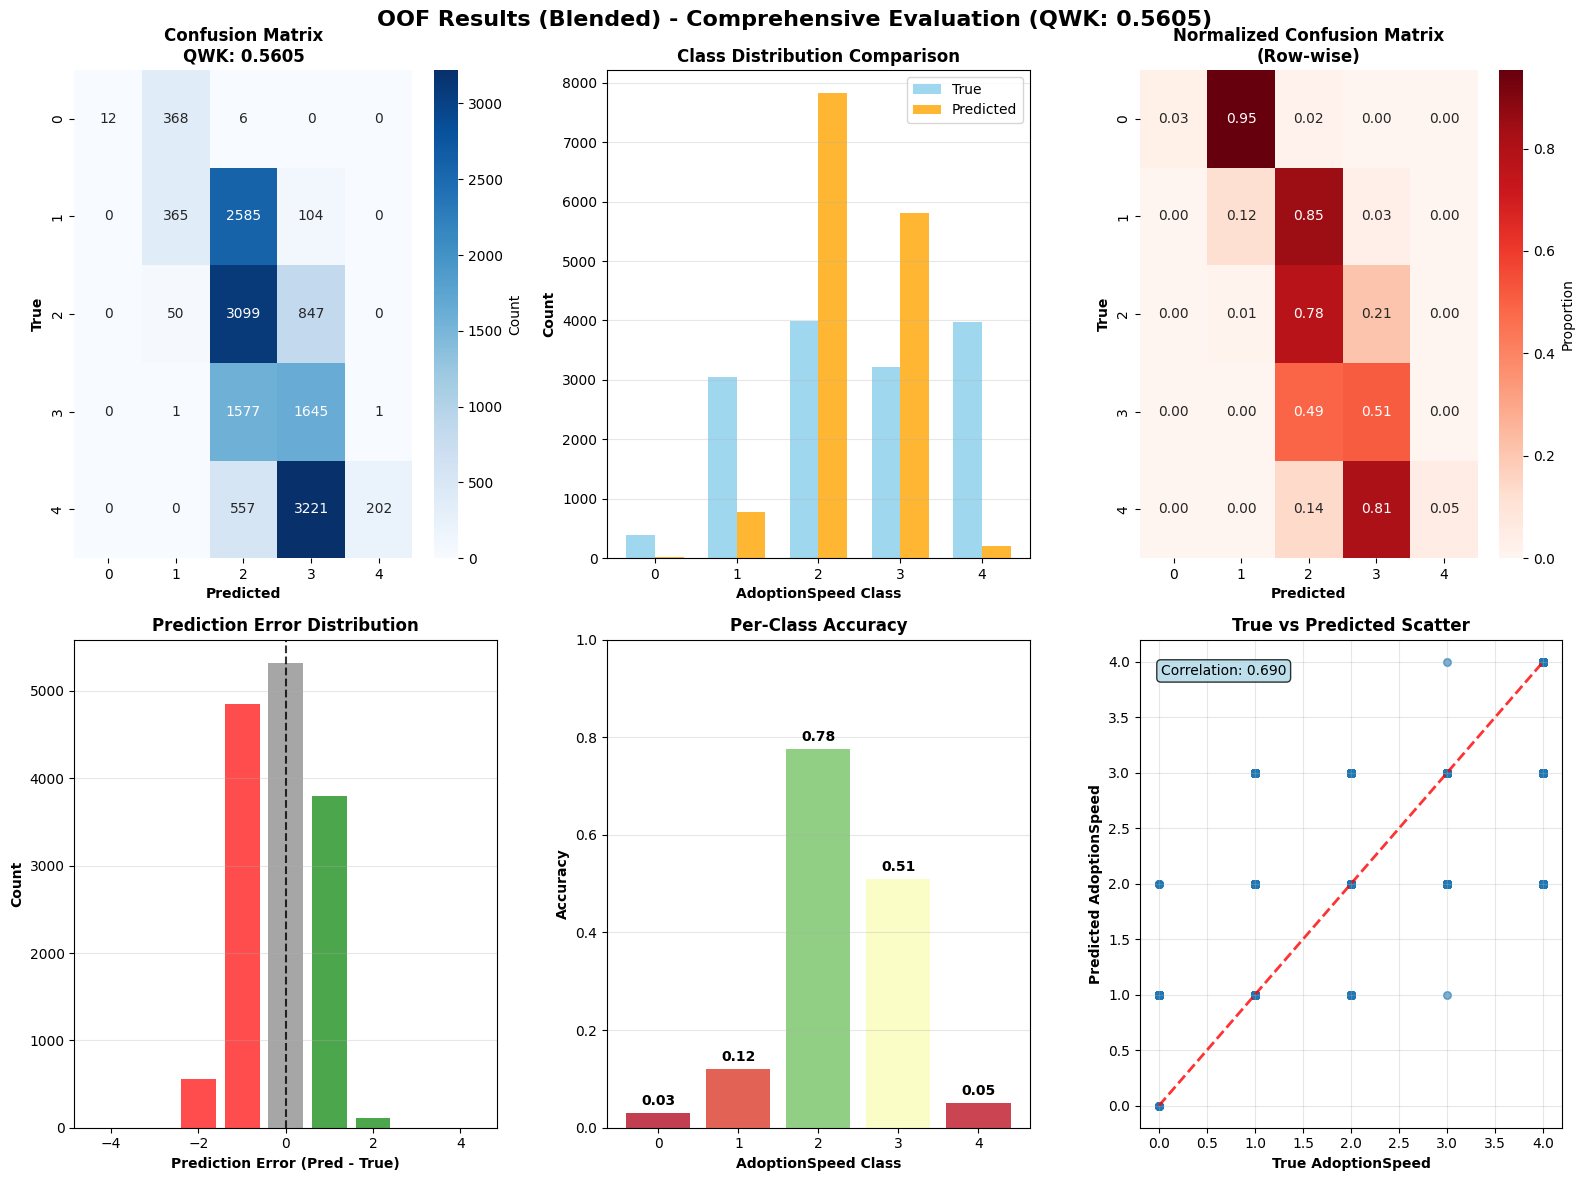

{'qwk': 0.5605182984793522,
 'confusion_matrix': array([[  12,  368,    6,    0,    0],
        [   0,  365, 2585,  104,    0],
        [   0,   50, 3099,  847,    0],
        [   0,    1, 1577, 1645,    1],
        [   0,    0,  557, 3221,  202]]),
 'class_accuracies': [0.031088082901554404,
  0.11951538965291421,
  0.7755255255255256,
  0.5102357320099256,
  0.05075376884422111],
 'correlation': 0.6902259641415269}

In [16]:
def train_and_evaluate(X, y, X_test, sample_weight, best_params):
    """Train and evaluate LightGBM model with cross-validation."""
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof = np.zeros(len(X))
    preds_test = np.zeros((len(X_test), folds.n_splits))
    for i, (tr_idx, val_idx) in enumerate(folds.split(X, y)):
        model = lgb.LGBMRegressor(**best_params)
        model.fit(X[tr_idx], y[tr_idx], sample_weight=sample_weight[tr_idx])
        oof[val_idx] = model.predict(X[val_idx])
        preds_test[:, i] = model.predict(X_test)
    return oof, preds_test.mean(axis=1)


def train_catboost(X, y, X_test, sample_weight):
    """Train CatBoost model and return OOF and test predictions."""
    model = CatBoostRegressor(
        iterations=400,
        learning_rate=0.04,
        depth=7,
        random_seed=42,
        verbose=0,
        loss_function="RMSE",
    )
    model.fit(X, y, sample_weight=sample_weight)
    return model.predict(X), model.predict(X_test)


def train_xgboost(X, y, X_test, sample_weight):
    """Train XGBoost model and return OOF and test predictions."""
    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=400,
        learning_rate=0.04,
        max_depth=7,
        random_state=42,
    )
    model.fit(X, y, sample_weight=sample_weight)
    return model.predict(X), model.predict(X_test)


oof_lgb, pred_lgb = train_and_evaluate(X_tab, y, X_test_tab, sample_weight, best_params)
oof_cat, pred_cat = train_catboost(X_tab, y, X_test_tab, sample_weight)
oof_xgb, pred_xgb = train_xgboost(X_tab, y, X_test_tab, sample_weight)

# Simple average stack
blended = (oof_lgb + oof_cat + oof_xgb) / 3
pred_blended = (pred_lgb + pred_cat + pred_xgb) / 3
round_preds = np.clip(np.round(blended), 0, 4).astype(int)
print("OOF QWK (blended):", quadratic_weighted_kappa(y, round_preds))
plot_detailed_results(y, round_preds, "OOF Results (Blended)")

## Final train and submission

In [17]:
class OptimizedRounder:
    """Find optimal rounding thresholds for regression → classes."""

    def __init__(self):
        self.coef_ = [0.5, 1.5, 2.5, 3.5]

    def _kappa_loss(self, coef, X, y):
        X_p = self.predict(X, coef)
        return -quadratic_weighted_kappa(y, X_p)

    def fit(self, X, y):
        from scipy.optimize import minimize

        loss_partial = lambda c: self._kappa_loss(c, X, y)
        initial_coef = self.coef_
        bounds = [(None, None)] * len(initial_coef)
        result = minimize(loss_partial, initial_coef, method="nelder-mead")
        self.coef_ = result.x

    def predict(self, X, coef=None):
        if coef is None:
            coef = self.coef_
        coef = np.sort(coef)
        X_p = np.digitize(X, coef)
        return X_p

    def coefficients(self):
        return self.coef_

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002701 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26584
[LightGBM] [Info] Number of data points in the train set: 14640, number of used features: 119
[LightGBM] [Info] Start training from score 2.000000


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


FINAL QWK (train, blended): 0.6487


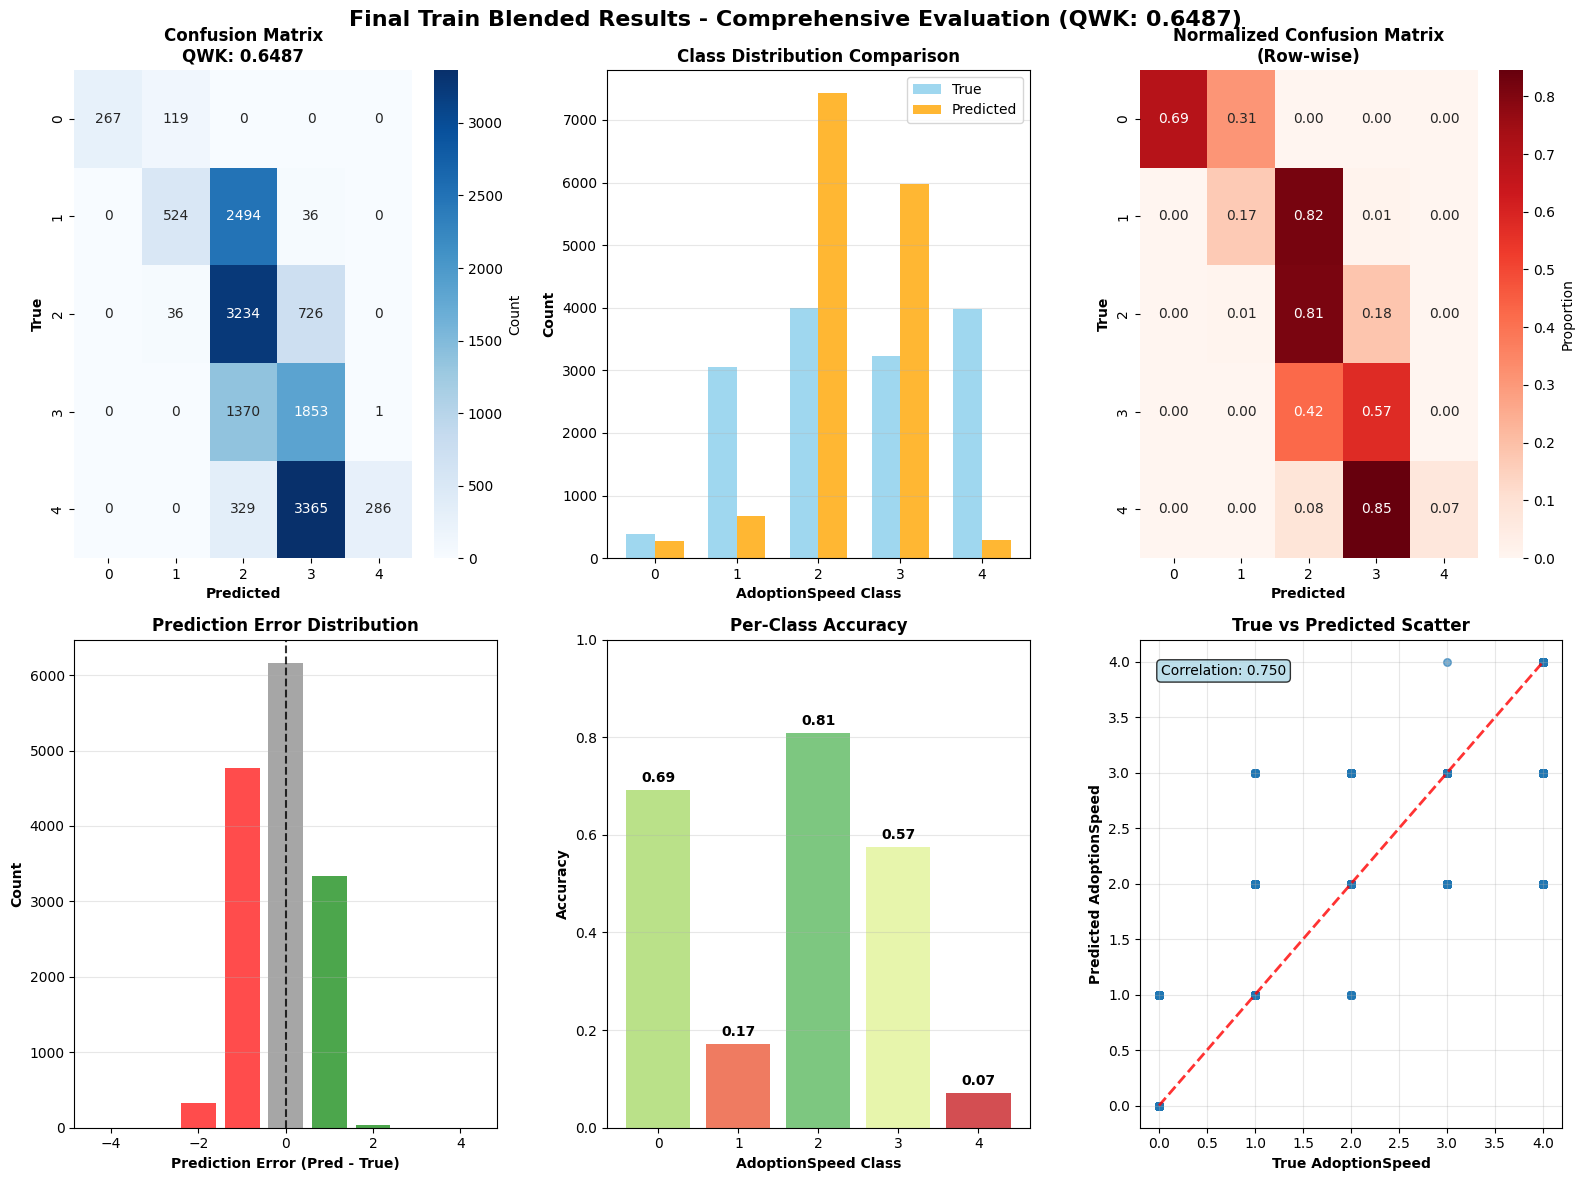

FINAL submission saved!


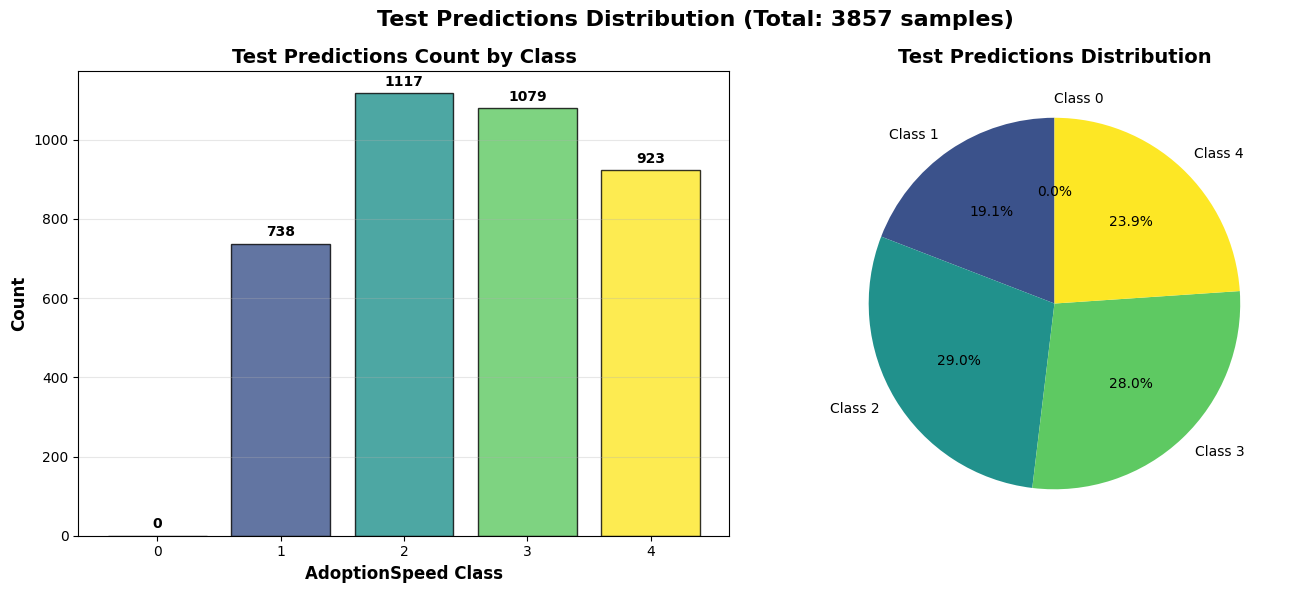


=== Test Predictions Distribution Summary ===
Total samples: 3857
Class 0:    0 (  0.0%)
Class 1:  738 ( 19.1%)
Class 2: 1117 ( 29.0%)
Class 3: 1079 ( 28.0%)
Class 4:  923 ( 23.9%)


In [18]:
lgb_final = lgb.LGBMRegressor(**best_params)
lgb_final.fit(X_tab, y, sample_weight=sample_weight)
lgb_pred_test = lgb_final.predict(X_test_tab)

cat_final = CatBoostRegressor(
    iterations=400,
    learning_rate=0.04,
    depth=7,
    random_seed=42,
    verbose=0,
    loss_function="RMSE",
)
cat_final.fit(X_tab, y, sample_weight=sample_weight)
cat_pred_test = cat_final.predict(X_test_tab)

xgb_final = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=400,
    learning_rate=0.04,
    max_depth=7,
    random_state=42,
)
xgb_final.fit(X_tab, y, sample_weight=sample_weight)
xgb_pred_test = xgb_final.predict(X_test_tab)

lgb_pred_train = lgb_final.predict(X_tab)
cat_pred_train = cat_final.predict(X_tab)
xgb_pred_train = xgb_final.predict(X_tab)
pred_blended_train = (lgb_pred_train + cat_pred_train + xgb_pred_train) / 3
round_blended_train = np.clip(np.round(pred_blended_train), 0, 4).astype(int)
qwk_final = quadratic_weighted_kappa(y, round_blended_train)
print(f"FINAL QWK (train, blended): {qwk_final:.4f}")
plot_detailed_results(y, round_blended_train, "Final Train Blended Results")

optR = OptimizedRounder()
optR.fit(blended, y)  # blended = (oof_lgb + oof_cat + oof_xgb) / 3
best_coef = optR.coefficients()

pred_blended_final = (lgb_pred_test + cat_pred_test + xgb_pred_test) / 3
final_preds = optR.predict(pred_blended_final, best_coef)
final_preds = np.clip(final_preds, 0, 4).astype(int)

submission = pd.DataFrame(
    {
        "PetID": test_df["PetID"],
        "AdoptionSpeed": final_preds,
    }
)
submission.to_csv(OUTPUTS / "submission.csv", index=False)
print("FINAL submission saved!")
plot_test_predictions_distribution(submission["AdoptionSpeed"].values)

Minority Class Report:
3    4866
2    2134
4     203
1       1
Name: count, dtype: int64


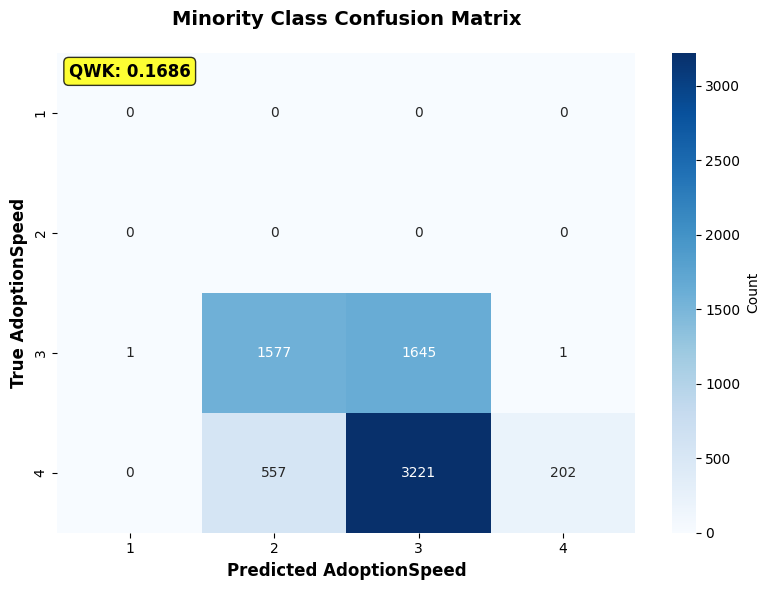

In [19]:
def analyze_minority_class(y_true, y_pred, minority_classes=[3, 4]):
    """Analyze and visualize results for minority classes."""
    mask = np.isin(y_true, minority_classes)
    print("Minority Class Report:")
    print(pd.Series(y_pred[mask]).value_counts())
    plot_confusion_matrix(
        y_true[mask], y_pred[mask], title="Minority Class Confusion Matrix"
    )


analyze_minority_class(y, round_preds)